# Spam Classification

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report

In [ ]:
# Text Preprocessing Libraries
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stem = PorterStemmer()

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


## Dataset

In [ ]:
df = pd.read_csv("../00_Datasets/emails.csv")

In [ ]:
df.head()

,Text,Spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## EDA

In [ ]:
df.shape

(5728, 2)

In [ ]:
df.columns

Index(['Text', 'Spam'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    5728 non-null   object
 1   Spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
df.isnull().sum()

Text    0
Spam    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(5695, 2)

In [ ]:
print(df.Spam.value_counts())

Spam
0    4327
1    1368
Name: count, dtype: int64


<Axes: xlabel='Spam', ylabel='count'>

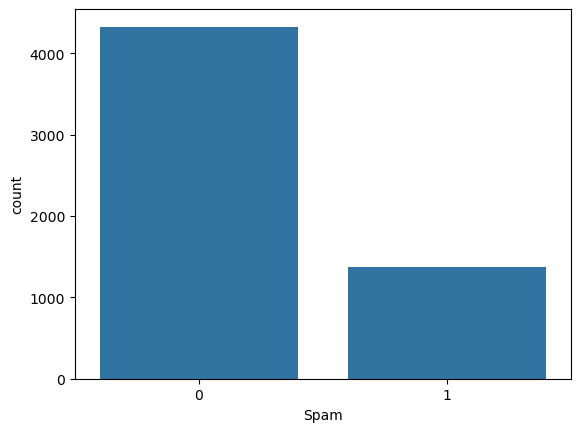

In [ ]:
sns.countplot(x='Spam', data=df)

## Text Cleaning

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
# This function cleans raw text by removing special characters, converting to lowercase, removing stopwords, applying stemming, and returning a normalized sentence for NLP modeling.

def clean_text(text):
    text = re.sub('[^a-zA-Z0-9]', ' ', str(text))
    text = text.lower()
    text = text.split()
    text = [
        stem.stem(word)
        for word in text
        if word not in stop_words
    ]
    return ' '.join(text)

In [ ]:
df['clean_text'] = df['Text'].apply(clean_text)

In [ ]:
df.shape

(5695, 3)

In [ ]:
df

,Text,Spam,clean_text
0,Subject: naturally irresistible your corporate...,1,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,subject money get softwar cd softwar compat gr...
...,...,...,...
5723,Subject: re : research and development charges...,0,subject research develop charg gpg forward shi...
5724,"Subject: re : receipts from visit jim , than...",0,subject receipt visit jim thank invit visit ls...
5725,Subject: re : enron case study update wow ! a...,0,subject enron case studi updat wow day super t...
5726,"Subject: re : interest david , please , call...",0,subject interest david pleas call shirley cren...


## Feature Extraction via TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text']) # input feature
y = df['Spam'] # output label

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model = Naive Bayes (MultinomialNB)

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

## Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 0, ..., 0, 1, 1])

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9841966637401229


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       843
           1       0.98      0.96      0.97       296

    accuracy                           0.98      1139
   macro avg       0.98      0.98      0.98      1139
weighted avg       0.98      0.98      0.98      1139



In [ ]:
y.value_counts()

Spam
0    4327
1    1368
Name: count, dtype: int64

## Testing

In [ ]:
msg = ["Hi, can we reschedule our meeting to tomorrow afternoon? Please let me know your availability."]
msg_clean = [clean_text(msg[0])]
msg_vector = vectorizer.transform(msg_clean)

print(model.predict(msg_vector))

[0]


In [ ]:
msg = ["Congratulations! You won a free iPhone. Call now to claim your prize"]
msg_clean = [clean_text(msg[0])]
msg_vector = vectorizer.transform(msg_clean)

print(model.predict(msg_vector))

[1]
